# CAGED Indústria SP — Análise SQL com DuckDB

**Stack:** Python · DuckDB · pandas · matplotlib
**Pergunta:** Como a indústria de transformação em SP se recuperou após 2020?

> **Dados reais:** Execute `01_download_dados.ipynb` e carregue `data/caged_sp_industria.parquet`.
> Este notebook usa dataset sintético para demonstração — estrutura idêntica ao CAGED real.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import json
from pathlib import Path

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0A0A0F",
    "axes.facecolor":   "#111118",
    "text.color":       "#E2E8F0",
    "axes.labelcolor":  "#94A3B8",
    "xtick.color":      "#64748B",
    "ytick.color":      "#64748B",
    "grid.color":       "#1E293B",
    "font.family":      "monospace",
})
ACCENT = "#00D4AA"
WARM   = "#F59E0B"
MUTED  = "#64748B"


In [2]:
np.random.seed(42)

municipios = {
    "355030": "São Paulo",
    "352900": "Guarulhos",
    "354340": "Osasco",
    "354870": "Santo André",
    "355220": "Sorocaba",
}

graus = {5: "Fund. Completo", 7: "Médio Completo", 8: "Sup. Incompleto", 9: "Sup. Completo"}
meses = pd.date_range("2021-01", "2024-01", freq="MS")

rows = []
for competencia in meses:
    for cod, nome in municipios.items():
        trend = (competencia.year - 2021) * 50 + competencia.month * 5
        base_saldo = {"355030": 200, "352900": 80, "354340": 60, "354870": 50, "355220": 45}
        saldo = int(base_saldo[cod] + trend + np.random.normal(0, 30))
        admissoes = max(500, 600 + trend + np.random.randint(-50, 50))
        desligamentos = admissoes - saldo

        for _ in range(5):
            grau = np.random.choice(list(graus.keys()), p=[0.15, 0.50, 0.20, 0.15])
            rows.append({
                "competencia":    competencia,
                "municipio_cod":  cod,
                "municipio_nome": nome,
                "secao":          "C",
                "saldo_mov":      saldo // 5,
                "admissoes":      admissoes // 5,
                "desligamentos":  desligamentos // 5,
                "salario_mensal": round(np.random.normal(3200 + grau * 200, 400), 2),
                "grau_instrucao": grau,
                "grau_label":     graus[grau],
                "sexo":           np.random.choice([1, 2]),
            })

df_caged = pd.DataFrame(rows)
conn = duckdb.connect()
conn.register("caged_sp_industria", df_caged)
print(f"Dataset sintético: {len(df_caged):,} registros | {df_caged['municipio_nome'].nunique()} municípios | {df_caged['competencia'].dt.year.nunique()} anos")
df_caged.head(3)


Dataset sintético: 925 registros | 5 municípios | 4 anos


,competencia,municipio_cod,municipio_nome,secao,saldo_mov,admissoes,desligamentos,salario_mensal,grau_instrucao,grau_label,sexo
0,2021-01-01,355030,São Paulo,C,43,125,81,4544.69,7,Médio Completo,1
1,2021-01-01,355030,São Paulo,C,43,125,81,4562.15,7,Médio Completo,1
2,2021-01-01,355030,São Paulo,C,43,125,81,4228.47,7,Médio Completo,2


## Query 1: Saldo Acumulado por Município
**Window function:** `SUM() OVER (PARTITION BY ... ORDER BY ...)`

In [3]:
query_saldo_acum = """
SELECT
    municipio_nome,
    competencia,
    saldo_mov,
    SUM(saldo_mov) OVER (
        PARTITION BY municipio_nome
        ORDER BY competencia
        ROWS UNBOUNDED PRECEDING
    ) AS saldo_acumulado
FROM caged_sp_industria
GROUP BY municipio_nome, competencia, saldo_mov
ORDER BY municipio_nome, competencia
"""
df_saldo = conn.execute(query_saldo_acum).df()
print(f"Resultado: {len(df_saldo)} linhas")
df_saldo.head(8)


Resultado: 185 linhas


,municipio_nome,competencia,saldo_mov,saldo_acumulado
0,Guarulhos,2021-01-01,17,17.0
1,Guarulhos,2021-02-01,9,26.0
2,Guarulhos,2021-03-01,26,52.0
3,Guarulhos,2021-04-01,26,78.0
4,Guarulhos,2021-05-01,13,91.0
5,Guarulhos,2021-06-01,13,104.0
6,Guarulhos,2021-07-01,14,118.0
7,Guarulhos,2021-08-01,25,143.0


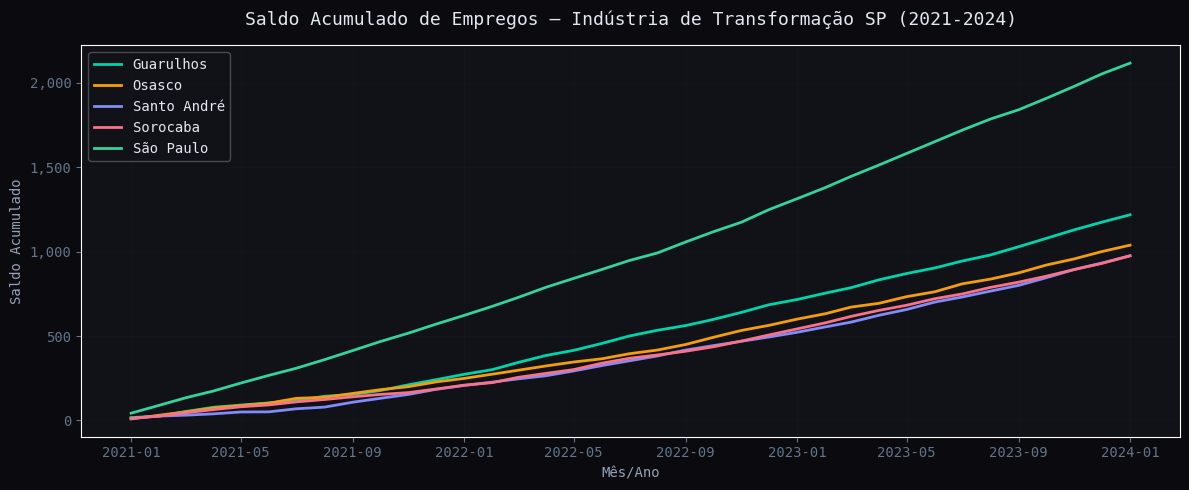

Gráfico 1: saldo acumulado por município


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = [ACCENT, WARM, "#818CF8", "#FB7185", "#34D399"]

for i, mun in enumerate(df_saldo["municipio_nome"].unique()):
    d = df_saldo[df_saldo["municipio_nome"] == mun]
    ax.plot(d["competencia"], d["saldo_acumulado"],
            label=mun, color=colors[i % len(colors)], linewidth=2)

ax.set_title("Saldo Acumulado de Empregos — Indústria de Transformação SP (2021-2024)",
             fontsize=13, pad=15, color="#E2E8F0")
ax.set_xlabel("Mês/Ano")
ax.set_ylabel("Saldo Acumulado")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", framealpha=0.3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../saldo_acumulado.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico 1: saldo acumulado por município")


## Query 2: Ranking de Recuperação Pós-2021
**CTE:** `WITH recuperacao AS (...)`

In [5]:
query_recuperacao = """
WITH recuperacao AS (
    SELECT
        municipio_nome,
        SUM(saldo_mov)      AS saldo_total,
        SUM(admissoes)      AS total_admissoes,
        SUM(desligamentos)  AS total_desligamentos
    FROM caged_sp_industria
    WHERE competencia >= '2021-06-01'
    GROUP BY municipio_nome
)
SELECT
    municipio_nome,
    saldo_total,
    total_admissoes,
    total_desligamentos,
    ROUND(total_admissoes * 100.0 / NULLIF(total_desligamentos, 0), 1) AS taxa_admissao_pct
FROM recuperacao
ORDER BY saldo_total DESC
"""
df_rec = conn.execute(query_recuperacao).df()
df_rec


,municipio_nome,saldo_total,total_admissoes,total_desligamentos,taxa_admissao_pct
0,São Paulo,9475.0,22020.0,12485.0,176.4
1,Guarulhos,5635.0,22640.0,16940.0,133.6
2,Osasco,4750.0,22165.0,17355.0,127.7
3,Santo André,4625.0,22000.0,17310.0,127.1
4,Sorocaba,4470.0,22205.0,17645.0,125.8


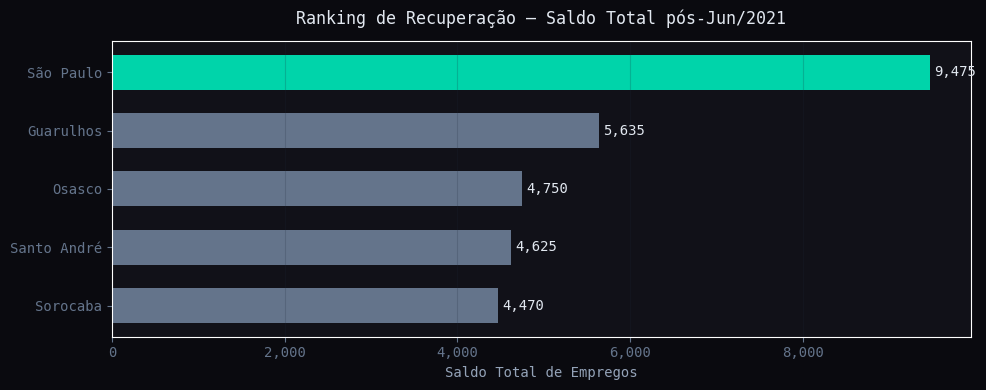

Gráfico 2: ranking de recuperação


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_rec["municipio_nome"], df_rec["saldo_total"],
               color=[ACCENT if i == 0 else MUTED for i in range(len(df_rec))],
               height=0.6)
ax.set_title("Ranking de Recuperação — Saldo Total pós-Jun/2021", fontsize=12, pad=12, color="#E2E8F0")
ax.set_xlabel("Saldo Total de Empregos")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
for bar, val in zip(bars, df_rec["saldo_total"]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=10, color="#E2E8F0")
plt.tight_layout()
plt.show()
print("Gráfico 2: ranking de recuperação")


## Query 3: Composição por Grau de Instrução
**Aggregation:** `GROUP BY` com múltiplas métricas

In [7]:
query_instrucao = """
SELECT
    grau_label,
    COUNT(*)                        AS registros,
    SUM(saldo_mov)                  AS saldo_total,
    ROUND(AVG(salario_mensal), 2)   AS salario_medio
FROM caged_sp_industria
GROUP BY grau_label
ORDER BY saldo_total DESC
"""
df_inst = conn.execute(query_instrucao).df()
df_inst


,grau_label,registros,saldo_total,salario_medio
0,Médio Completo,459,15314.0,4619.84
1,Sup. Incompleto,178,6401.0,4815.83
2,Fund. Completo,152,5251.0,4157.34
3,Sup. Completo,136,4644.0,5031.30


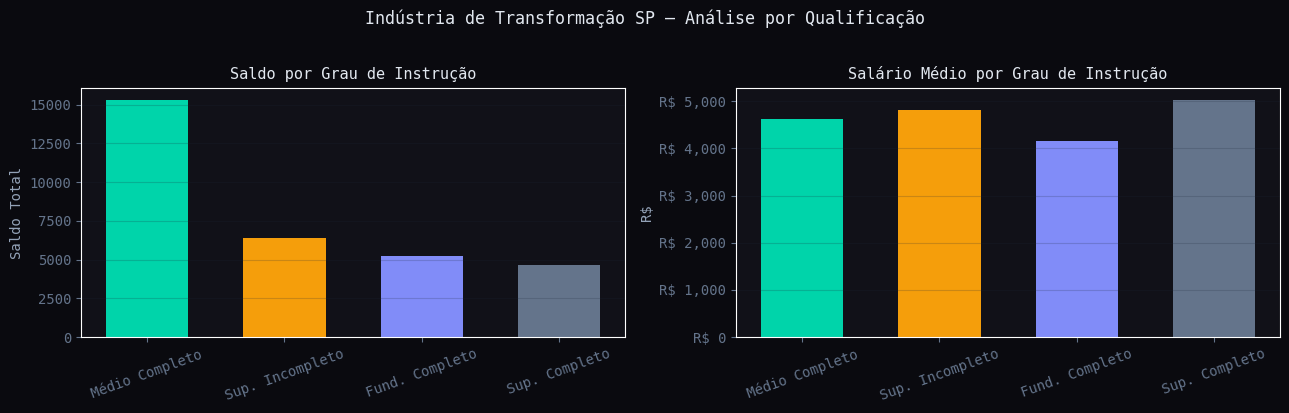

Gráfico 3: composição por grau de instrução


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors_inst = [ACCENT, WARM, "#818CF8", MUTED]
ax1.bar(df_inst["grau_label"], df_inst["saldo_total"],
        color=colors_inst[:len(df_inst)], width=0.6)
ax1.set_title("Saldo por Grau de Instrução", fontsize=11, color="#E2E8F0")
ax1.set_ylabel("Saldo Total")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.2)

ax2.bar(df_inst["grau_label"], df_inst["salario_medio"],
        color=colors_inst[:len(df_inst)], width=0.6)
ax2.set_title("Salário Médio por Grau de Instrução", fontsize=11, color="#E2E8F0")
ax2.set_ylabel("R$")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="y", alpha=0.2)

plt.suptitle("Indústria de Transformação SP — Análise por Qualificação",
             fontsize=12, y=1.02, color="#E2E8F0")
plt.tight_layout()
plt.show()
print("Gráfico 3: composição por grau de instrução")


In [9]:
portfolio_data = {
    "meta": {
        "fonte": "Novo CAGED/MTE (dados sintéticos para demonstração)",
        "periodo": "2021-2024",
        "uf": "SP",
        "secao": "C - Indústria de Transformação",
        "gerado_em": pd.Timestamp.now().strftime("%Y-%m-%d")
    },
    "municipios": []
}

for mun_nome in df_caged["municipio_nome"].unique():
    df_mun = (df_caged[df_caged["municipio_nome"] == mun_nome]
              .groupby("competencia")
              .agg(saldo_mov=("saldo_mov","sum"), admissoes=("admissoes","sum"),
                   desligamentos=("desligamentos","sum"))
              .reset_index()
              .sort_values("competencia"))

    portfolio_data["municipios"].append({
        "nome": mun_nome,
        "serie": [
            {
                "competencia": str(row["competencia"])[:7],
                "saldo":       int(row["saldo_mov"]),
                "admissoes":   int(row["admissoes"]),
                "desligamentos": int(row["desligamentos"])
            }
            for _, row in df_mun.iterrows()
        ]
    })

output_path = Path("V:/Portifolio/data/caged-sp-municipios.json")
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(portfolio_data, f, ensure_ascii=False, indent=2)

print(f"Exportado: {output_path}")
print(f"   Municípios: {len(portfolio_data['municipios'])}")
print(f"   Períodos por município: {len(portfolio_data['municipios'][0]['serie'])}")


Exportado: V:\Portifolio\data\caged-sp-municipios.json
   Municípios: 5
   Períodos por município: 37
